In [1]:
# Importando as bibliotecas necessárias.
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Reset o gerador de sequências PN.
seed = 42
np.random.seed(seed)

### Gerando o conjunto de dados.

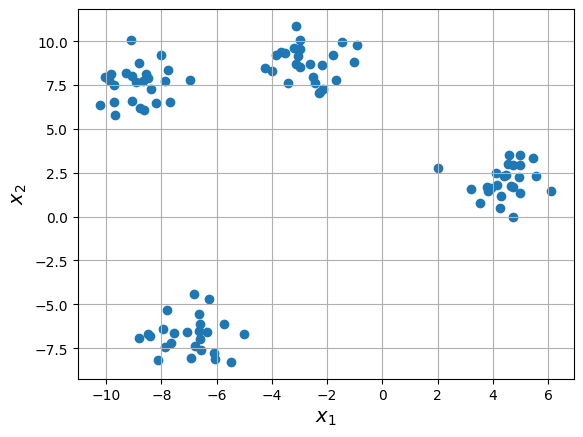

In [3]:
# Define número de exemplos.
N = 100

X, _ = make_blobs(n_samples=N, centers=4, random_state=seed)

plt.scatter(X[:,0], X[:,1])
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.grid()
plt.show()

## Econtrando o número de clusters

Vamos usar o método do coeficiente de silhueta para descobrir o melhor número de clusters.

Ele avalia a qualidade da clusterização, considerando a coesão dentro dos clusters e a separação entre eles.

Escolhemos o número de clusters que maximiza o coeficiente.

In [4]:
import numpy as np
# Testando diferentes valores de K
K_range = range(2, 11)

silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=seed
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

    print(f"K = {k:2d} | Silhouette = {score:.4f}")

K =  2 | Silhouette = 0.5925
K =  3 | Silhouette = 0.7577
K =  4 | Silhouette = 0.7937
K =  5 | Silhouette = 0.7042
K =  6 | Silhouette = 0.5654
K =  7 | Silhouette = 0.4678
K =  8 | Silhouette = 0.4528
K =  9 | Silhouette = 0.4651
K = 10 | Silhouette = 0.3484


In [5]:
# Melhor K
best_k = K_range[np.argmax(silhouette_scores)]

print("\nMelhor número de clusters =", best_k)


Melhor número de clusters = 4


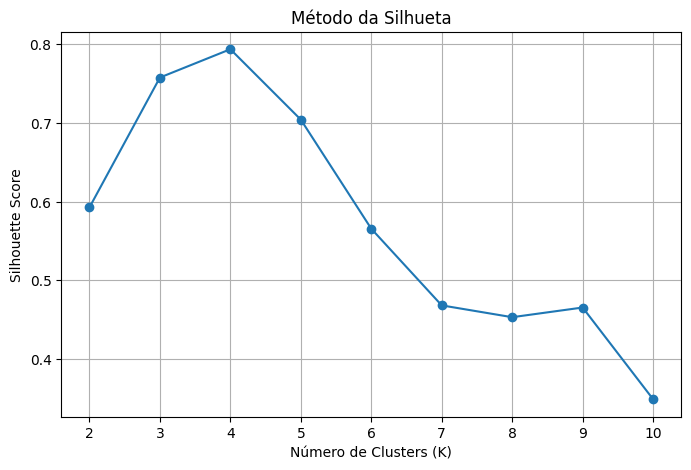

In [6]:
# Gráfico
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Método da Silhueta")
plt.grid(True)
plt.show()

### Usando o melhor número de clusters.

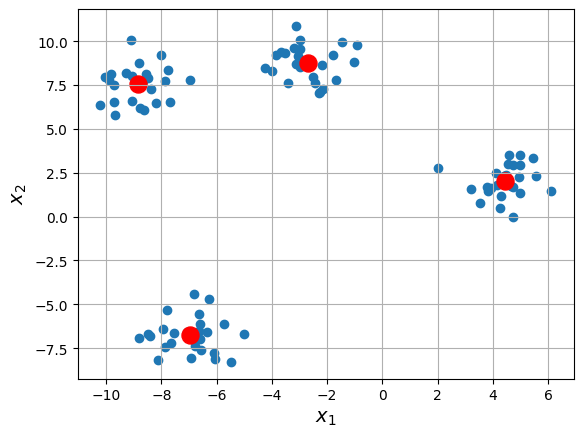

In [7]:
# Instancia objeto da classe KMeans.
kmeans = KMeans(n_clusters=best_k, random_state=seed)

# Treina objeto da classe KMeans.
kmeans.fit(X)

plt.scatter(X[:,0], X[:,1])
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=150, c='red')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.grid()
plt.show()